In [34]:
import os
import math
import time
import hashlib
import logging
import sqlite3
from typing import List, Dict, Tuple
import numpy as np
import nltk
import faiss
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [35]:
nltk.download('punkt', quiet=True)

True

In [36]:
# === CONFIG ===
BATCH_SIZE = 16                    # embeddings batch size
TARGET_CHUNK_TOKENS = 400          # desired chunk size (tokens)
MIN_CLUSTER_COUNT = 2
EMBED_DIM = None                   # auto-detect after first embedding
FAISS_INDEX_PATH = "faiss.index"
SQLITE_PATH = "metadata.db"

In [37]:
# ---------------------------------------
# Load Azure OpenAI Client
# ---------------------------------------
from openai import AzureOpenAI

client = AzureOpenAI(
    api_key=os.environ["AZURE_OPENAI_KEY"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    api_version="2023-10-01-preview"
)

# Embedding deployment name
DEPLOYMENT = os.environ["OPENAI_DEPLOYMENT_NAME"]


In [38]:
def get_embeddings(texts: List[str]) -> np.ndarray:
    """
    Returns np.ndarray of shape (N, dim)
    """
    resp = client.embeddings.create(
        model=DEPLOYMENT,
        input=texts
    )
    embs = [np.array(item.embedding, dtype=np.float32) for item in resp.data]
    return np.vstack(embs)


In [39]:
# --------------------------
# Utilities
# --------------------------
def sha256_hex(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def sentence_split(text: str) -> List[str]:
    return nltk.tokenize.sent_tokenize(text)

def count_tokens(text: str) -> int:
    # prefer tiktoken if available; fallback to words
    try:
        import tiktoken
        enc = tiktoken.get_encoding("cl100k_base")
        return len(enc.encode(text))
    except Exception:
        return len(text.split())

In [40]:
# === DB for metadata (demo: sqlite). Use Postgres in real prod. ===
def init_metadata_store(path=SQLITE_PATH):
    conn = sqlite3.connect(path)
    cur = conn.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS chunks (
        chunk_id TEXT PRIMARY KEY,
        doc_id TEXT,
        chunk_index INTEGER,
        text TEXT,
        token_start INTEGER,
        token_end INTEGER,
        sentence_start INTEGER,
        sentence_end INTEGER,
        embedding_vector BLOB,
        embedding_model VARCHAR(128),
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )""")
    conn.commit()
    return conn

def persist_chunk_metadata(conn, chunk_meta: Dict, embedding: np.ndarray, model_name: str = "azure-emb"):
    # embedding -> bytes
    emb_bytes = embedding.astype(np.float32).tobytes()
    cur = conn.cursor()
    cur.execute("""
        INSERT OR REPLACE INTO chunks (
            chunk_id, doc_id, chunk_index, text, token_start, token_end,
            sentence_start, sentence_end, embedding_vector, embedding_model)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        chunk_meta["chunk_id"], chunk_meta["doc_id"], chunk_meta["chunk_index"],
        chunk_meta["text"], chunk_meta["token_start"], chunk_meta["token_end"],
        chunk_meta["sentence_start"], chunk_meta["sentence_end"],
        emb_bytes, model_name
    ))
    conn.commit()

In [41]:
# --------------------------
# Semantic chunking via clustering
# --------------------------
def semantic_chunk_document(doc_id: str, text: str, target_chunk_tokens: int = TARGET_CHUNK_TOKENS) -> List[Dict]:
    sentences = sentence_split(text)
    print(f"sentences : {sentences}")
    if not sentences:
        return []

    token_counts = [count_tokens(s) for s in sentences]
    print(f"token_counts : {token_counts}")
    total_tokens = sum(token_counts)

    # Estimate number of chunks/clusters
    est_k = max(MIN_CLUSTER_COUNT, math.ceil(total_tokens / float(max(1, target_chunk_tokens))))
    k = min(est_k, len(sentences))

    # 1) embed sentences in batches
    sent_embs = []
    for i in range(0, len(sentences), BATCH_SIZE):
        batch = sentences[i:i+BATCH_SIZE]
        emb = np.asarray(get_embeddings(batch), dtype=np.float32)  # shape (batch, dim)
        sent_embs.append(emb)
    sent_embs = np.vstack(sent_embs)  # (n_sentences, dim)

    global EMBED_DIM
    EMBED_DIM = EMBED_DIM or sent_embs.shape[1]

    # 2) cluster sentences (KMeans works well; agglomerative also possible)
    if k <= 1:
        labels = np.zeros(len(sentences), dtype=int)
    else:
        km = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = km.fit_predict(sent_embs)
        print(f"labels : {labels}")

    # 3) build clusters -> chunks preserving sentence order within cluster
    buckets = {}
    for i, lab in enumerate(labels):
        buckets.setdefault(int(lab), []).append(i)

    print(f"buckets : {buckets}")

    # order clusters by earliest sentence index (keeps reading order)
    ordered_clusters = sorted(list(buckets.items()), key=lambda x: min(x[1]))
    print(f"ordered_clusters : {ordered_clusters}")

    chunks = []
    chunk_index = 0
    for lab, sent_idxs in ordered_clusters:
        sent_idxs_sorted = sorted(sent_idxs)
        chunk_text = " ".join([sentences[i] for i in sent_idxs_sorted])
        token_start = sum(token_counts[:sent_idxs_sorted[0]]) if sent_idxs_sorted else 0
        token_end = sum(token_counts[:sent_idxs_sorted[-1]+1]) if sent_idxs_sorted else 0
        chunk_id = f"{doc_id}::chunk::{chunk_index}"
        chunks.append({
            "chunk_id": chunk_id,
            "doc_id": doc_id,
            "chunk_index": chunk_index,
            "text": chunk_text,
            "token_start": token_start,
            "token_end": token_end,
            "sentence_start": sent_idxs_sorted[0],
            "sentence_end": sent_idxs_sorted[-1]
        })
        chunk_index += 1

    # 4) optional: merge too-small chunks with neighbor (left or right)
    # implement merging strategy if needed (omitted for brevity)
    return chunks, sent_embs, labels

In [11]:
# --------------------------
# FAISS index helpers
# --------------------------
def build_faiss_index(embs: np.ndarray, use_hnsw: bool = True) -> faiss.Index:
    assert faiss is not None, "faiss not installed"
    dim = embs.shape[1]
    if use_hnsw:
        # HNSW index for inner product (we will normalize vectors for cosine)
        index = faiss.IndexHNSWFlat(dim, 32)  # 32 efConstruction default
        faiss.normalize_L2(embs)
        index.add(embs)
    else:
        # flat index (exact) - fine for small corpora
        index = faiss.IndexFlatIP(dim)
        faiss.normalize_L2(embs)
        index.add(embs)
    return index

def save_faiss(index, path=FAISS_INDEX_PATH):
    faiss.write_index(index, path)

def load_faiss(path=FAISS_INDEX_PATH):
    return faiss.read_index(path)

In [12]:
# --------------------------
# Ingest pipeline (one document)
# --------------------------
def ingest_document(doc_id: str, text: str, conn, faiss_index=None, faiss_offset: int = 0):
    # 1) semantic chunk
    chunks, sent_embs, labels = semantic_chunk_document(doc_id, text, TARGET_CHUNK_TOKENS)

    # 2) compute chunk embeddings (embedding each chunk text)
    chunk_texts = [c["text"] for c in chunks]
    if not chunk_texts:
        return faiss_offset

    chunk_embs = np.vstack(get_embeddings(chunk_texts)).astype(np.float32)  # (n_chunks, dim)
    # normalize embeddings for cosine/inner-product
    if faiss is not None:
        faiss.normalize_L2(chunk_embs)

    # 3) add to FAISS (if provided)
    if faiss_index is not None:
        faiss_index.add(chunk_embs)  # using normalized vectors if normalized above

    # 4) persist metadata with embedding bytes
    for c, emb in zip(chunks, chunk_embs):
        persist_chunk_metadata(conn, c, emb)
    return faiss_offset + len(chunks)


In [13]:
# --------------------------
# Query helper
# --------------------------
def query_index(query: str, faiss_index, metadata_conn, top_k: int = 5):
    q_emb = np.asarray(get_embeddings([query]), dtype=np.float32)
    faiss.normalize_L2(q_emb)
    D, I = faiss_index.search(q_emb, top_k)  # returns distances & indices
    results = []
    cur = metadata_conn.cursor()
    for score, idx in zip(D[0], I[0]):
        # fetch metadata by rowid or chunk_id mapping (this demo assumes 1-1 ordering)
        # In prod store a mapping table from faiss idx -> chunk_id
        cur.execute("SELECT chunk_id, doc_id, text FROM chunks LIMIT 1 OFFSET ?", (idx,))
        row = cur.fetchone()
        if row:
            results.append({"chunk_id": row[0], "doc_id": row[1], "text": row[2], "score": float(score)})
    return results

In [14]:
logging.basicConfig(level=logging.INFO)

In [15]:
conn = init_metadata_store(SQLITE_PATH)

In [16]:
# create empty faiss index if faiss available
faiss_idx = None
if faiss is not None:
    # For demo create empty index; in prod you will persist and load
    # Need dim after first embedding; here we will infer after first doc
    pass

In [17]:
# Example ingest
doc_id = "doc1"
text = open("sample_long_text.txt", "r", encoding="utf-8").read()

# run ingest: build chunks, compute chunk embeddings and persist metadata
# For demo we will compute chunk embeddings and create faiss index after that
chunks, sent_embs, labels = semantic_chunk_document(doc_id, text)
chunk_texts = [c["text"] for c in chunks]
chunk_embs = np.vstack(get_embeddings(chunk_texts)).astype(np.float32)
if faiss is not None:
    faiss.normalize_L2(chunk_embs)
    faiss_idx = build_faiss_index(chunk_embs, use_hnsw=True)
    save_faiss(faiss_idx, FAISS_INDEX_PATH)
# persist metadata
for c, emb in zip(chunks, chunk_embs):
    persist_chunk_metadata(conn, c, emb)
print("Ingested", len(chunks), "chunks")

sentences : ['Artificial Intelligence (AI) has rapidly moved from a niche research topic to a foundation technology\nthat impacts nearly every industry.', 'Over the past decade, improvements in model architectures,\nincreases in compute, and the availability of large-scale datasets have combined to produce models\nthat perform complex perceptual and cognitive tasks at or above human levels in narrow domains.', 'Machine learning (ML) is the primary engine behind modern AI.', 'ML techniques allow models to discover\npatterns in data and generalize to unseen inputs.', 'Supervised learning, which uses labeled examples,\nhas driven progress in classification, object detection, and many structured prediction tasks.', 'Unsupervised learning, which finds structure without labels, includes clustering, dimensionality reduction,\nand certain generative methods.', 'Reinforcement learning trains agents to act in an environment through\ntrial and error using reward signals and has powered advances i

INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"


labels : [2 2 2 2 2 2 2 2 2 2 2 0 0 2 0 0 0 0 2 2 0 0 0 0 0 0 0 0 2 2 3 3 3 3 3 3 3
 3 3 3 3 3 0 0 0 0 2 2 3 0 0 0 3 3 1 3 1 3 1 3 1 3 1 3 1 0 0 3 3 3 0]
buckets : {2: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 18, 19, 28, 29, 46, 47], 0: [11, 12, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 42, 43, 44, 45, 49, 50, 51, 65, 66, 70], 3: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 48, 52, 53, 55, 57, 59, 61, 63, 67, 68, 69], 1: [54, 56, 58, 60, 62, 64]}
ordered_clusters : [(2, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 18, 19, 28, 29, 46, 47]), (0, [11, 12, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 42, 43, 44, 45, 49, 50, 51, 65, 66, 70]), (3, [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 48, 52, 53, 55, 57, 59, 61, 63, 67, 68, 69]), (1, [54, 56, 58, 60, 62, 64])]


INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"


Ingested 4 chunks


In [18]:
# %%
# Sanity checks: chunks, embeddings and DB
print("Number of chunks:", len(chunks))
print("Sent embeddings shape (per-sentence) :", sent_embs.shape if 'sent_embs' in globals() else "none")
print("Chunk embeddings shape :", chunk_embs.shape if 'chunk_embs' in globals() else "none")
try:
    print("FAISS index present:", faiss_idx is not None)
except Exception:
    print("FAISS index variable not defined")
# show first 3 chunks preview
for i, c in enumerate(chunks[:3]):
    print(f"\n--- chunk {i} id={c['chunk_id']} tokens≈{c.get('token_end', '?')-c.get('token_start',0)}")
    print(c['text'][:400].replace("\n", " "))


Number of chunks: 4
Sent embeddings shape (per-sentence) : (71, 1536)
Chunk embeddings shape : (4, 1536)
FAISS index present: True

--- chunk 0 id=doc1::chunk::0 tokens≈1069
Artificial Intelligence (AI) has rapidly moved from a niche research topic to a foundation technology that impacts nearly every industry. Over the past decade, improvements in model architectures, increases in compute, and the availability of large-scale datasets have combined to produce models that perform complex perceptual and cognitive tasks at or above human levels in narrow domains. Machine 

--- chunk 1 id=doc1::chunk::1 tokens≈1055
Data is the lifeblood of machine learning. Curating, cleaning, and annotating high-quality datasets is often the costliest part of building a practical system. Still, dataset bias, labeling errors, and distribution shift remain persistent challenges. Monitoring data drift and having a robust evaluation strategy are essential to maintaining model performance over time. Model evalu

tokens per chunk - mean, median, min, max: 337.0 434.0 17 463


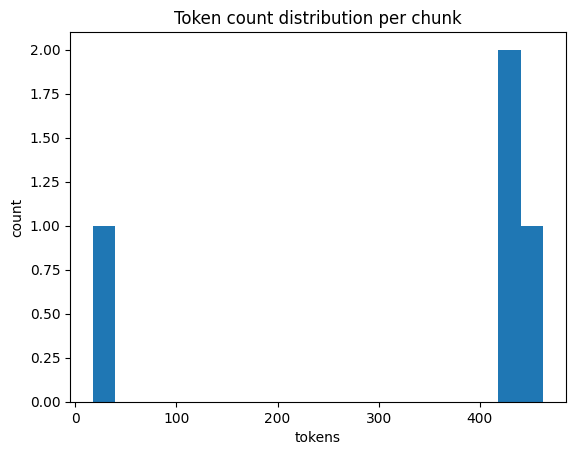

In [19]:
# %%
# token counts per chunk (requires count_tokens)
tok_counts = [count_tokens(c['text']) for c in chunks]
import numpy as np
print("tokens per chunk - mean, median, min, max:", np.mean(tok_counts), np.median(tok_counts), min(tok_counts), max(tok_counts))

# show histogram (simple)
import matplotlib.pyplot as plt
plt.hist(tok_counts, bins=20)
plt.title("Token count distribution per chunk")
plt.xlabel("tokens")
plt.ylabel("count")
plt.show()


In [20]:
# %%
# verify normalization (if faiss normalized)
if 'chunk_embs' in globals():
    norms = np.linalg.norm(chunk_embs, axis=1)
    print("embedding norms - mean, min, max:", float(norms.mean()), float(norms.min()), float(norms.max()))
else:
    print("chunk_embs not available")


embedding norms - mean, min, max: 1.0 0.9999999403953552 1.0


In [21]:
# %%
# Save and reload FAISS index to ensure persistence works
if faiss is None:
    print("FAISS not installed — skipping save/load test")
else:
    # save
    save_faiss(faiss_idx, FAISS_INDEX_PATH)
    print("Saved faiss to", FAISS_INDEX_PATH)
    # load back
    loaded = load_faiss(FAISS_INDEX_PATH)
    print("Loaded FAISS index. ntotal:", loaded.ntotal)
    # sanity search: run a self-query using first chunk
    q = chunks[0]['text'][:200]
    q_emb = np.asarray(get_embeddings([q]), dtype=np.float32)
    faiss.normalize_L2(q_emb)
    D, I = loaded.search(q_emb, 3)
    print("Top indices for first-chunk sample:", I[0], "scores:", D[0])


Saved faiss to faiss.index
Loaded FAISS index. ntotal: 4


INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"


Top indices for first-chunk sample: [0 1 2] scores: [0.5117667 0.8858724 1.3073221]


In [22]:
q2 = "Why RAG is so useful"
q_emb2 = np.asarray(get_embeddings([q2]), dtype=np.float32)
faiss.normalize_L2(q_emb2)
D, I = loaded.search(q_emb2, 4)
print("Top indices for first-chunk sample:", I[0], "scores:", D[0])

INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"


Top indices for first-chunk sample: [2 1 0 3] scores: [0.9954357 1.5149301 1.5877376 1.7339783]


In [23]:
# %%
# Interactive query loop. Type a query and press Enter. Empty input quits.
# Uses FAISS if available, otherwise uses simple dot-product search on chunk_embs.

def search_with_faiss(q, top_k=5):
    q_emb = np.asarray(get_embeddings([q]), dtype=np.float32)
    faiss.normalize_L2(q_emb)
    D, I = faiss_idx.search(q_emb, top_k)
    results = []
    cur = conn.cursor()
    for score, idx in zip(D[0], I[0]):
        cur.execute("SELECT chunk_id, doc_id, text FROM chunks LIMIT 1 OFFSET ?", (int(idx),))
        row = cur.fetchone()
        if row:
            results.append({"chunk_id": row[0], "doc_id": row[1], "text": row[2], "score": float(score)})
    return results

def search_fallback(q, top_k=5):
    # build normalized index from chunk_embs if not using FAISS
    embs = chunk_embs if 'chunk_embs' in globals() else None
    if embs is None:
        raise RuntimeError("chunk_embs not found for fallback search")
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    norms[norms==0]=1.0
    idx_mat = embs / norms
    q_emb = np.asarray(get_embeddings([q]), dtype=np.float32)
    q_emb = q_emb / (np.linalg.norm(q_emb, axis=1, keepdims=True) + 1e-12)
    sims = (idx_mat @ q_emb.T).reshape(-1)
    top_idx = np.argsort(sims)[::-1][:top_k]
    results = []
    for idx in top_idx:
        cur = conn.cursor()
        cur.execute("SELECT chunk_id, doc_id, text FROM chunks LIMIT 1 OFFSET ?", (int(idx),))
        row = cur.fetchone()
        if row:
            results.append({"chunk_id": row[0], "doc_id": row[1], "text": row[2], "score": float(sims[idx])})
    return results

# print("Interactive search. Empty query to exit.")
# while True:
q = "RAG application in IT sector."
# q = input("Query> ").strip()
# if not q:
#     print("Exiting interactive search.")
#     break
start = time.time()
if faiss is not None and faiss_idx is not None:
    res = search_with_faiss(q, top_k=5)
else:
    res = search_fallback(q, top_k=5)
duration = time.time() - start
print(f"\nTop {len(res)} results (took {duration:.3f}s):")
for i, r in enumerate(res):
    print(f"{i+1}. chunk_id={r['chunk_id']} score={r['score']:.4f}")
    print(r['text'][:400].replace("\n", " "))
    print("-"*80)


INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"



Top 5 results (took 0.306s):
1. chunk_id=doc1::chunk::2 score=1.1949
Retrieval-augmented generation (RAG) is a technique where an external knowledge source (documents, databases) is retrieved and fed into a generator so the model can produce grounded, up-to-date responses. RAG systems typically consist of a retriever (dense or sparse), an index, and a generator (LLM). Chunking documents into passages is a core step for indexing and retrieval. Chunking design choice
--------------------------------------------------------------------------------
2. chunk_id=doc1::chunk::1 score=1.5717
Data is the lifeblood of machine learning. Curating, cleaning, and annotating high-quality datasets is often the costliest part of building a practical system. Still, dataset bias, labeling errors, and distribution shift remain persistent challenges. Monitoring data drift and having a robust evaluation strategy are essential to maintaining model performance over time. Model evaluation uses a combi
-------

In [24]:
# %%
# Auto-suggest: find sentences containing keywords to help label ground-truth
def suggest_chunks_for_keyword(keyword, top_n=10):
    keyword = keyword.lower()
    suggestions = []
    cur = conn.cursor()
    cur.execute("SELECT chunk_id, text FROM chunks")
    for row in cur.fetchall():
        if keyword in row[1].lower():
            suggestions.append(row[0])
    return suggestions[:top_n]

# Example:
print(suggest_chunks_for_keyword("transformer"))
print(suggest_chunks_for_keyword("data drift"))


['doc1::chunk::0']
['doc1::chunk::1']


In [25]:
# %%
# Example test_queries: replace with your labeled chunk ids
test_queries = [
    # {"query": "...", "relevant_chunk_ids": ["doc1::chunk::2"]},
]

# Example: fill one manually using suggestion output, e.g.
# test_queries.append({"query":"How do transformers help NLP?", "relevant_chunk_ids":["doc1::chunk::2"]})

def evaluate_retrieval(test_queries, top_k_list=[1,3,5], use_faiss=False):
    import numpy as np
    metrics = {k: {"recall":0, "precision":0} for k in top_k_list}
    mrr_sum = 0.0
    times = []
    n = len(test_queries)
    for tq in test_queries:
        q = tq["query"]
        relevant = set(tq["relevant_chunk_ids"])
        t0 = time.time()
        if use_faiss and faiss is not None and faiss_idx is not None:
            res = search_with_faiss(q, top_k=max(top_k_list))
            retrieved_ids = [r["chunk_id"] for r in res]
        else:
            res = search_fallback(q, top_k=max(top_k_list))
            retrieved_ids = [r["chunk_id"] for r in res]
        t1 = time.time()
        times.append(t1-t0)
        for k in top_k_list:
            topk = retrieved_ids[:k]
            if len(set(topk) & relevant) > 0:
                metrics[k]["recall"] += 1
            metrics[k]["precision"] += len(set(topk) & relevant) / float(k)
        # MRR
        rr = 0.0
        for rank, rid in enumerate(retrieved_ids, start=1):
            if rid in relevant:
                rr = 1.0/rank
                break
        mrr_sum += rr
    # finalize
    out = {"n_queries": n, "avg_latency": float(np.mean(times)) if times else None}
    for k in top_k_list:
        out[f"recall@{k}"] = metrics[k]["recall"] / n if n else None
        out[f"precision@{k}"] = metrics[k]["precision"] / n if n else None
    out["MRR"] = mrr_sum / n if n else None
    return out

# Run when you have test_queries
if test_queries:
    metrics = evaluate_retrieval(test_queries, top_k_list=[1,3,5], use_faiss=(faiss is not None and faiss_idx is not None))
    print(metrics)
else:
    print("No test_queries defined. Create test_queries by labeling some queries using suggest_chunks_for_keyword.")


No test_queries defined. Create test_queries by labeling some queries using suggest_chunks_for_keyword.


In [26]:
chunks[0]

{'chunk_id': 'doc1::chunk::0',
 'doc_id': 'doc1',
 'chunk_index': 0,
 'text': 'Artificial Intelligence (AI) has rapidly moved from a niche research topic to a foundation technology\nthat impacts nearly every industry. Over the past decade, improvements in model architectures,\nincreases in compute, and the availability of large-scale datasets have combined to produce models\nthat perform complex perceptual and cognitive tasks at or above human levels in narrow domains. Machine learning (ML) is the primary engine behind modern AI. ML techniques allow models to discover\npatterns in data and generalize to unseen inputs. Supervised learning, which uses labeled examples,\nhas driven progress in classification, object detection, and many structured prediction tasks. Unsupervised learning, which finds structure without labels, includes clustering, dimensionality reduction,\nand certain generative methods. Reinforcement learning trains agents to act in an environment through\ntrial and error 

In [27]:
# %%
# 1) Suggest frequent keywords from the whole corpus to help seed queries
import collections
import json
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

def top_corpus_keywords(chunks, top_k=40, min_len=3):
    sw = set(stopwords.words('english'))
    counter = collections.Counter()
    for c in chunks:
        # simple tokenization: words only
        words = re.findall(r"[A-Za-z']+", c['text'].lower())
        words = [w for w in words if w not in sw and len(w) >= min_len]
        counter.update(words)
    return [w for w, _ in counter.most_common(top_k)]

# Run and show suggestions
keywords = top_corpus_keywords(chunks, top_k=60)
print("Top suggested keywords (inspect and pick ones that look meaningful):")
print(", ".join(keywords[:40]))


Top suggested keywords (inspect and pick ones that look meaningful):
models, data, learning, model, retrieval, passages, systems, training, large, techniques, language, generation, retrieved, tasks, many, metrics, evaluation, size, index, overlap, chunks, impacts, architectures, datasets, human, uses, prediction, neural, networks, raw, often, provide, precision, inference, efficient, reduce, privacy, production, design, rag


In [28]:
# %%
# 2) Suggest candidate chunk ids for a keyword (shows previews)
def suggest_chunks_for_keyword(keyword, limit=20):
    keyword_l = keyword.lower()
    cur = conn.cursor()
    cur.execute("SELECT chunk_id, text FROM chunks")
    suggestions = []
    for row in cur.fetchall():
        cid, text = row[0], row[1]
        if keyword_l in text.lower():
            # preview: highlight keyword and first 250 chars
            low = text.lower()
            idx = low.find(keyword_l)
            start = max(0, idx - 60)
            preview = text[start:start+300].replace("\n", " ")
            suggestions.append((cid, preview))
    return suggestions[:limit]

# Example usage:
print("Example candidate chunks for keyword 'transformer':")
for cid, pv in suggest_chunks_for_keyword("transformer")[:6]:
    print(cid, "->", pv[:200], "...")


Example candidate chunks for keyword 'transformer':
doc1::chunk::0 -> e understanding; recurrent neural networks (RNNs) and later transformers revolutionized sequence modeling. The transformer architecture, introduced in 2017, enabled highly-parallel training and attent ...


In [29]:
# %%
# 3) Interactive labeling loop to build test_queries
import json

test_queries = []  # will store {"query":..., "relevant_chunk_ids":[...], "notes":...}

print("Interactive labeling tool.")
print("Instructions:")
print("  - Enter a keyword to search chunk previews (or ENTER to exit).")
print("  - After seeing candidates, type a query you want to label.")
print("  - Then type comma-separated chunk_ids (or indices) from the shown list as relevant evidence.")
print()

while True:
    keyword = input("Keyword (ENTER to finish) > ").strip()
    if not keyword:
        break

    # show suggestions
    candidates = suggest_chunks_for_keyword(keyword, limit=30)
    if not candidates:
        print("No candidate chunks found for that keyword. Try another keyword.\n")
        continue

    print(f"\nFound {len(candidates)} candidate chunks containing '{keyword}':")
    for i, (cid, preview) in enumerate(candidates):
        print(f"[{i}] {cid} -> {preview[:240]}...")
    print()

    # ask for the human query to label
    query_text = input("Enter the evaluation query to label (a question): ").strip()
    if not query_text:
        print("Empty query — skipping.\n")
        continue

    # ask which candidate(s) are relevant
    sel = input("Enter comma-separated indices of relevant candidates (e.g. 0,2) or enter explicit chunk_ids: ").strip()
    if not sel:
        print("No selection — skipping.\n")
        continue

    # normalize selection into chunk ids
    chosen_ids = []
    parts = [s.strip() for s in sel.split(",") if s.strip()]
    for p in parts:
        # if looks like an integer index (refers to candidates list)
        if re.fullmatch(r"\d+", p):
            idx = int(p)
            if 0 <= idx < len(candidates):
                chosen_ids.append(candidates[idx][0])
            else:
                print(f"Index {idx} out of range, ignored.")
        else:
            # assume user typed a chunk_id
            chosen_ids.append(p)

    if not chosen_ids:
        print("No valid chunk ids selected — skipping.\n")
        continue

    notes = input("Optional notes (press Enter to skip): ").strip()
    item = {"query": query_text, "relevant_chunk_ids": chosen_ids, "notes": notes}
    test_queries.append(item)
    print(f"Saved labeled query. Total labeled: {len(test_queries)}\n")

    # quick save option
    auto_save = input("Save current test_queries to 'test_queries.json'? (y/N) ").strip().lower()
    if auto_save == "y":
        with open("test_queries.json", "w", encoding="utf-8") as f:
            json.dump(test_queries, f, indent=2)
        print("Saved to test_queries.json\n")

print("\nLabeling session finished.")
print(f"Total labeled queries: {len(test_queries)}")
# final save
if test_queries:
    with open("test_queries.json", "w", encoding="utf-8") as f:
        json.dump(test_queries, f, indent=2)
    print("Saved test_queries.json")


Interactive labeling tool.
Instructions:
  - Enter a keyword to search chunk previews (or ENTER to exit).
  - After seeing candidates, type a query you want to label.
  - Then type comma-separated chunk_ids (or indices) from the shown list as relevant evidence.

No candidate chunks found for that keyword. Try another keyword.


Found 1 candidate chunks containing 'RAG':
[0] doc1::chunk::2 -> Retrieval-augmented generation (RAG) is a technique where an external knowledge source (documents, databases) is retrieved and fed into a generator so the model can produce grounded, up-to-date responses. RAG systems typically consist of a ...

Empty query — skipping.


Labeling session finished.
Total labeled queries: 0


In [30]:
# %%
# 4) Load & inspect labeled queries
import json, os
if os.path.exists("test_queries.json"):
    with open("test_queries.json", "r", encoding="utf-8") as f:
        test_queries = json.load(f)
    print("Loaded", len(test_queries), "queries from test_queries.json")
    for i, t in enumerate(test_queries[:20]):
        print(i, "Q:", t["query"], "| relevant:", t["relevant_chunk_ids"], "| notes:", t.get("notes"))
else:
    print("test_queries.json not found. Run the labeling loop first.")


Loaded 23 queries from test_queries.json
0 Q: How is artificial intelligence transforming industries? | relevant: ['doc1::chunk::0'] | notes: Intro + AI impact on industries
1 Q: What are the main types of machine learning? | relevant: ['doc1::chunk::1'] | notes: Supervised, unsupervised, reinforcement
2 Q: Explain supervised learning. | relevant: ['doc1::chunk::1'] | notes: Supervised learning explanation
3 Q: What does unsupervised learning do? | relevant: ['doc1::chunk::1'] | notes: Clustering, dimensionality reduction
4 Q: How does reinforcement learning work? | relevant: ['doc1::chunk::1'] | notes: Rewards and punishments
5 Q: What is deep learning and what architectures does it use? | relevant: ['doc1::chunk::2'] | notes: Deep learning, CNNs, RNNs, Transformers
6 Q: What is the transformer architecture and why is it important? | relevant: ['doc1::chunk::2'] | notes: Transformer intro + parallel training + attention
7 Q: What challenges arise from dataset bias? | relevant: ['doc1:

In [31]:
# %%
# 5) Evaluate retrieval using the test_queries you just labeled
# (reuse the evaluate_retrieval function cell you already added earlier)
# If not present, add the evaluation function cell from earlier, then run this.

metrics = evaluate_retrieval(test_queries, top_k_list=[1,3,5], use_faiss=(faiss is not None and faiss_idx is not None))
print("Evaluation metrics:", metrics)


INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/dep

Evaluation metrics: {'n_queries': 23, 'avg_latency': 0.33595425149668817, 'recall@1': 0.08695652173913043, 'precision@1': 0.08695652173913043, 'recall@3': 0.30434782608695654, 'precision@3': 0.10144927536231883, 'recall@5': 0.391304347826087, 'precision@5': 0.07826086956521738, 'MRR': 0.2028985507246377}


In [32]:
# %%
# fetch a specific chunk by id
def get_chunk_by_id(chunk_id):
    cur = conn.cursor()
    cur.execute("SELECT chunk_id, doc_id, chunk_index, token_start, token_end, sentence_start, sentence_end, text FROM chunks WHERE chunk_id = ?", (chunk_id,))
    return cur.fetchone()

# Example:
example_id = chunks[0]['chunk_id']
print("DB row:", get_chunk_by_id(example_id))


DB row: ('doc1::chunk::0', 'doc1', 0, 0, 1069, 0, 47, 'Artificial Intelligence (AI) has rapidly moved from a niche research topic to a foundation technology\nthat impacts nearly every industry. Over the past decade, improvements in model architectures,\nincreases in compute, and the availability of large-scale datasets have combined to produce models\nthat perform complex perceptual and cognitive tasks at or above human levels in narrow domains. Machine learning (ML) is the primary engine behind modern AI. ML techniques allow models to discover\npatterns in data and generalize to unseen inputs. Supervised learning, which uses labeled examples,\nhas driven progress in classification, object detection, and many structured prediction tasks. Unsupervised learning, which finds structure without labels, includes clustering, dimensionality reduction,\nand certain generative methods. Reinforcement learning trains agents to act in an environment through\ntrial and error using reward signals and

In [33]:
# %%
# embedding latency
t0 = time.time()
_ = get_embeddings(["This is a quick latency test"] * 1)
print("Embedding single call latency:", time.time() - t0)

# retrieval latency (excluding embed)
t0 = time.time()
_ = search_with_faiss("test") if (faiss is not None and faiss_idx is not None) else search_fallback("test")
print("Retrieval (excl embed) latency:", time.time() - t0)


INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"


Embedding single call latency: 1.0793721675872803


INFO:httpx:HTTP Request: POST https://pa-auth-openai.openai.azure.com/openai/deployments/azureopenai-text-embedding-3-small/embeddings?api-version=2023-10-01-preview "HTTP/1.1 200 OK"


Retrieval (excl embed) latency: 0.29658961296081543
